# Results viewer — multi-modal experiments vs. the BIG-TB baseline

Every experiment under `results/experiments/<name>/summary.csv` is a full
per-drug sweep. Each folder is one **model / modality configuration**; the
exact modalities used per drug live in that CSV's `modalities` column
(regulatory is only added where promoter FASTAs exist, so it appears for a
subset of drugs).

This notebook loads them all, lines up the held-out **test AUC** per drug,
and asks two questions:

1. **Does adding modalities beat DNA-only?** — Δ test AUC vs. the `dna` run.
2. **How does our best config compare to the published baseline?** — vs. the
   BIG-TB 1D CNN.

**Baseline source:** Tasmin et al., *"BIG-TB: A benchmark for prediction and
interpretability of sequence-based machine learning using Mtb"*, **Table 4**
(Test AUC, DNA inputs). `SD-CNN (OHE)` — the *single-drug* 1D CNN on one-hot
DNA — is the apples-to-apples baseline (our models are also single-drug).

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

In [2]:
# --- config ---
# This notebook lives in <project>/scripts/; find the project holding results.
_candidates = [
    Path("/home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion"),
    Path.cwd().parent,
    Path.cwd(),
]
PROJECT = next(
    (p for p in _candidates if (p / "results/experiments").is_dir()),
    _candidates[0],
)
EXP_DIR = PROJECT / "results/experiments"
print("Reading experiments from:", EXP_DIR)

# Readable label + display order per experiment folder. Folders found on disk
# but not listed here still load (labeled by folder name), appended at the end.
EXP_LABELS = {
    "dna":                 "DNA",
    "dna_protein":         "DNA + protein",
    "dna_biophysical":     "DNA + biophysical",
    "dna_regulatory":      "DNA + regulatory",
    "all_modalities":      "All modalities",
}
REFERENCE_EXP = "dna"   # multimodal gains are measured against this run

found = sorted(p.name for p in EXP_DIR.iterdir()
               if (p / "summary.csv").exists())
EXPERIMENTS = [e for e in EXP_LABELS if e in found] + \
              [e for e in found if e not in EXP_LABELS]
LABEL = {e: EXP_LABELS.get(e, e) for e in EXPERIMENTS}
print(f"{len(EXPERIMENTS)} experiments:", ", ".join(EXPERIMENTS))
_unlabeled = [e for e in EXPERIMENTS if e not in EXP_LABELS]
if _unlabeled:
    print("  (no readable label, shown by folder name):", ", ".join(_unlabeled))

# BIG-TB 1D CNN baseline (Tasmin et al., Table 4 — Test AUC, DNA one-hot).
#                     drug : (SD-CNN, MD-CNN)
BIGTB_1DCNN = {
    "AMIKACIN":     (0.845, 0.899),
    "CAPREOMYCIN":  (0.873, 0.829),
    "ETHAMBUTOL":   (0.931, 0.936),
    "ETHIONAMIDE":  (0.670, 0.709),
    "ISONIAZID":    (0.917, 0.951),
    "KANAMYCIN":    (0.849, 0.875),
    "LEVOFLOXACIN": (0.839, 0.850),
    "MOXIFLOXACIN": (0.886, 0.887),
    "PYRAZINAMIDE": (0.930, 0.908),
    "RIFAMPICIN":   (0.977, 0.981),
    "STREPTOMYCIN": (0.911, 0.938),
}
BASELINE_COL = "SD-CNN"   # "SD-CNN" (single-drug) or "MD-CNN" (multi-drug)

Reading experiments from: /home/jacksonmicha_umass_edu/abr_workspace/biophysical-fusion/results/experiments
5 experiments: dna, dna_protein, dna_biophysical, dna_regulatory, all_modalities


In [3]:
# --- load every experiment into one long frame + a wide test-AUC pivot ---
frames = []
for exp in EXPERIMENTS:
    s = pd.read_csv(EXP_DIR / exp / "summary.csv")
    s["drug"] = s["drug"].str.upper()
    s["experiment"] = exp
    s["label"] = LABEL[exp]
    frames.append(s)
long = pd.concat(frames, ignore_index=True)

# wide: drug x experiment -> test AUC
auc = long.pivot(index="drug", columns="experiment", values="test_auc")[EXPERIMENTS]
auc.columns = [LABEL[c] for c in auc.columns]

# BIG-TB baseline, aligned to our drugs
base = pd.DataFrame(
    [(d, sd, md) for d, (sd, md) in BIGTB_1DCNN.items()],
    columns=["drug", "SD-CNN", "MD-CNN"],
).set_index("drug")
auc = auc.join(base[[BASELINE_COL]].rename(columns={BASELINE_COL: f"BIG-TB {BASELINE_COL}"}))

# order drugs by our best config, best on top
our_cols = [LABEL[e] for e in EXPERIMENTS]
auc = auc.loc[auc[our_cols].max(axis=1).sort_values(ascending=False).index]
print(auc.round(3))

                DNA  DNA + protein  DNA + biophysical  DNA + regulatory  \
drug                                                                      
LEVOFLOXACIN  0.895          0.983              0.977             0.903   
RIFAMPICIN    0.976          0.973              0.973             0.973   
ISONIAZID     0.914          0.913              0.921             0.950   
KANAMYCIN     0.901          0.905              0.904             0.940   
STREPTOMYCIN  0.930          0.928              0.934             0.934   
ETHAMBUTOL    0.923          0.924              0.924             0.924   
PYRAZINAMIDE  0.868          0.882              0.894             0.893   
AMIKACIN      0.880          0.873              0.886             0.881   
CAPREOMYCIN   0.873          0.865              0.863             0.860   
MOXIFLOXACIN  0.757          0.784              0.770             0.789   
ETHIONAMIDE   0.529          0.704              0.680             0.740   

              All modali

In [4]:
# --- table: test AUC per drug x experiment, best of OUR configs in bold ---
our_cols = [LABEL[e] for e in EXPERIMENTS]
base_col = f"BIG-TB {BASELINE_COL}"

def _bold_row_best(row):
    best = row[our_cols].max()
    return ["font-weight: bold" if (c in our_cols and v == best) else ""
            for c, v in row.items()]

(auc.style
    .format("{:.3f}", na_rep="—")
    .background_gradient(subset=our_cols, cmap="Blues", vmin=0.5, vmax=1.0, axis=None)
    .apply(_bold_row_best, axis=1)
    .set_caption("Held-out test AUC. Bold = best of our configs per drug; "
                 f"last column = BIG-TB {BASELINE_COL} 1D CNN."))

,DNA,DNA + protein,DNA + biophysical,DNA + regulatory,All modalities,BIG-TB SD-CNN
drug,,,,,,
LEVOFLOXACIN,0.895,0.983,0.977,0.903,0.977,0.839
RIFAMPICIN,0.977,0.973,0.973,0.973,0.973,0.977
ISONIAZID,0.913,0.913,0.921,0.950,0.952,0.917
KANAMYCIN,0.901,0.905,0.904,0.940,0.926,0.849
STREPTOMYCIN,0.929,0.928,0.933,0.934,0.934,0.911
ETHAMBUTOL,0.923,0.924,0.924,0.924,0.926,0.931
PYRAZINAMIDE,0.868,0.882,0.894,0.893,0.872,0.930
AMIKACIN,0.879,0.873,0.885,0.881,0.876,0.845
CAPREOMYCIN,0.873,0.865,0.863,0.860,0.874,0.873


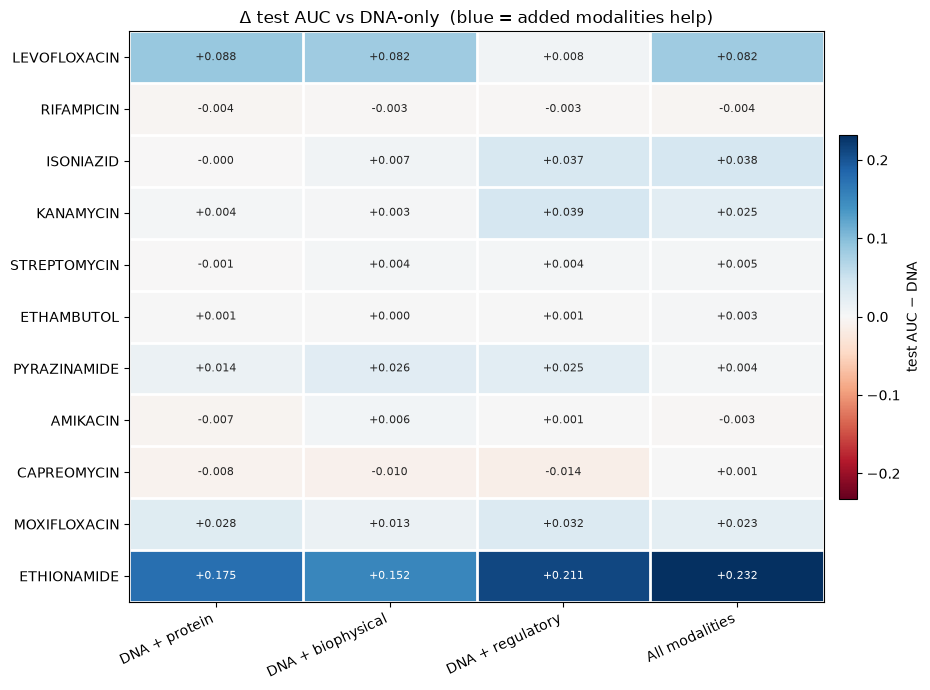

In [5]:
# --- where do extra modalities help? Δ test AUC vs the DNA-only run ---
# Diverging: blue = the config beats DNA-only, red = it trails. Gray at 0.
ref_label = LABEL[REFERENCE_EXP]
gain_cols = [c for c in our_cols if c != ref_label]
delta = auc[gain_cols].sub(auc[ref_label], axis=0)

vmax = float(np.nanmax(np.abs(delta.values)))
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

fig, ax = plt.subplots(figsize=(1.6 * len(gain_cols) + 3, 0.5 * len(delta) + 1.5))
im = ax.imshow(delta.values, cmap="RdBu", norm=norm, aspect="auto")
ax.set_xticks(range(len(gain_cols)), gain_cols, rotation=25, ha="right")
ax.set_yticks(range(len(delta)), delta.index)
for i in range(delta.shape[0]):
    for j in range(delta.shape[1]):
        v = delta.values[i, j]
        if np.isnan(v):
            continue
        ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=8,
                color="white" if abs(v) > 0.6 * vmax else "0.15")
ax.set_title(f"Δ test AUC vs {ref_label}-only  (blue = added modalities help)")
cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label(f"test AUC − {ref_label}")
ax.set_xticks(np.arange(-.5, len(gain_cols), 1), minor=True)
ax.set_yticks(np.arange(-.5, len(delta), 1), minor=True)
ax.grid(which="minor", color="white", lw=2)
ax.tick_params(which="minor", length=0)
plt.tight_layout()
plt.show()

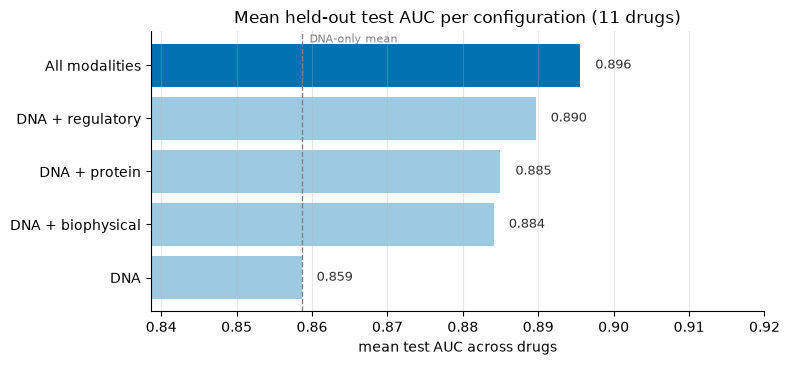

In [6]:
# --- does stacking modalities help on average? mean test AUC per config ---
means = auc[our_cols].mean().sort_values()
best_label = means.idxmax()
BLUE, HILITE = "#9ecae1", "#0072B2"   # muted blue, best config in strong blue
colors = [HILITE if c == best_label else BLUE for c in means.index]

fig, ax = plt.subplots(figsize=(8, 0.55 * len(means) + 1))
ax.barh(means.index, means.values, color=colors)
for y, v in enumerate(means.values):
    ax.text(v + 0.002, y, f"{v:.3f}", va="center", fontsize=9, color="0.2")
ax.axvline(auc[LABEL[REFERENCE_EXP]].mean(), color="0.5", lw=1, ls="--")
ax.text(auc[LABEL[REFERENCE_EXP]].mean(), len(means) - 0.4, "  DNA-only mean",
        color="0.5", fontsize=8, va="top")
ax.set_xlabel("mean test AUC across drugs")
ax.set_xlim(min(means.min() - 0.02, 0.85), max(means.max() + 0.02, 0.92))
ax.set_title("Mean held-out test AUC per configuration (11 drugs)")
ax.grid(axis="x", alpha=0.3)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

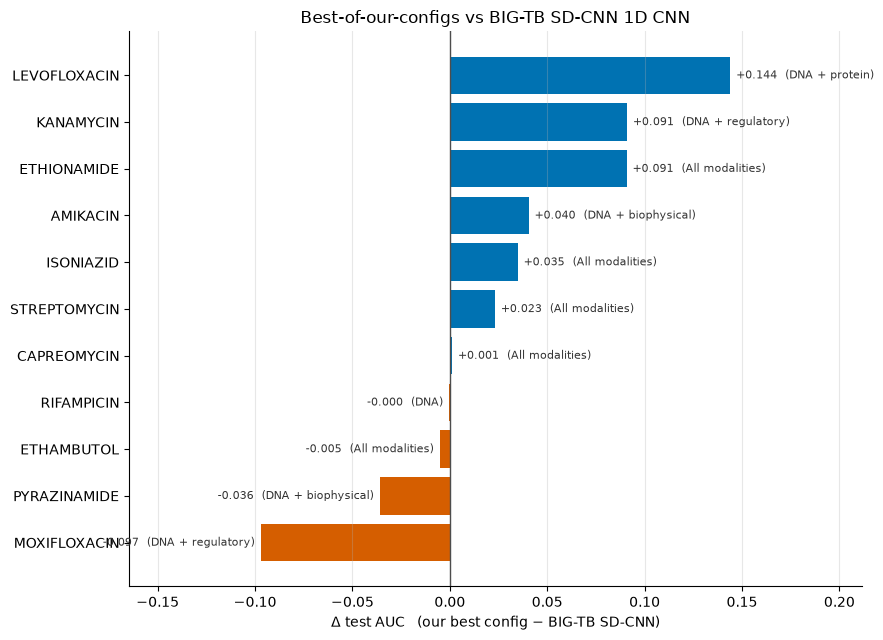

In [7]:
# --- our BEST config per drug vs the BIG-TB baseline ---
best = pd.DataFrame({
    "best_auc":  auc[our_cols].max(axis=1),
    "best_from": auc[our_cols].idxmax(axis=1),
    "baseline":  auc[base_col],
})
best["delta"] = best["best_auc"] - best["baseline"]
best = best.dropna(subset=["baseline"]).sort_values("delta")

POS, NEG = "#0072B2", "#D55E00"   # Okabe-Ito blue / vermillion (CVD-safe)
colors = [POS if v >= 0 else NEG for v in best["delta"]]

fig, ax = plt.subplots(figsize=(9, 0.5 * len(best) + 1))
ax.barh(best.index, best["delta"], color=colors)
ax.axvline(0, color="0.3", lw=1)
for y, (v, src) in enumerate(zip(best["delta"], best["best_from"])):
    ax.text(v + (0.003 if v >= 0 else -0.003), y,
            f"{v:+.3f}  ({src})", va="center",
            ha="left" if v >= 0 else "right", fontsize=8, color="0.2")
ax.set_xlabel(f"Δ test AUC   (our best config − BIG-TB {BASELINE_COL})")
ax.set_title(f"Best-of-our-configs vs BIG-TB {BASELINE_COL} 1D CNN")
ax.margins(x=0.28)
ax.grid(axis="x", alpha=0.3)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
plt.tight_layout()
plt.show()

In [8]:
# --- headline numbers ---
print("Mean test AUC per configuration (across 11 drugs):")
for c in sorted(our_cols, key=lambda c: auc[c].mean(), reverse=True):
    print(f"  {c:<22} {auc[c].mean():.4f}")

ref_label = LABEL[REFERENCE_EXP]
gain_cols = [c for c in our_cols if c != ref_label]
delta = auc[gain_cols].sub(auc[ref_label], axis=0)
n_cells = int(delta.notna().sum().sum())
n_up = int((delta > 0).sum().sum())
print(f"\nvs {ref_label}-only: {n_up}/{n_cells} (drug, config) cells improve; "
      f"mean Δ = {np.nanmean(delta.values):+.4f}")

cmp = best.dropna(subset=["baseline"])
print(f"\nBest-of-ours vs BIG-TB {BASELINE_COL}:")
print(f"  match / beat baseline : {int((cmp['delta'] >= 0).sum())}/{len(cmp)}")
print(f"  mean   Δ AUC          : {cmp['delta'].mean():+.4f}")
print(f"  best   : {cmp['delta'].idxmax():<13} ({cmp['delta'].max():+.3f})")
print(f"  worst  : {cmp['delta'].idxmin():<13} ({cmp['delta'].min():+.3f})")

Mean test AUC per configuration (across 11 drugs):
  All modalities         0.8956
  DNA + regulatory       0.8896
  DNA + protein          0.8850
  DNA + biophysical      0.8841
  DNA                    0.8586

vs DNA-only: 33/44 (drug, config) cells improve; mean Δ = +0.0300

Best-of-ours vs BIG-TB SD-CNN:
  match / beat baseline : 7/11
  mean   Δ AUC          : +0.0260
  best   : LEVOFLOXACIN  (+0.144)
  worst  : MOXIFLOXACIN  (-0.097)
